In [9]:
import pandas as pd
import numpy as np

# Load Dataset
df = pd.read_csv("/content/drive/MyDrive/dataset.csv")

#Initial Inspection
print(" Top RAW TRANSACTIONS")
print(df.head(10))

print(" BOTTOM RAW TRANSACTIONS ")
print(df.tail(10))

# Shape of your dataset
rows, cols = df.shape
print(f"\n[INFO] Dataset Dimensions: {rows} Rows and {cols} Columns")
print("\nDATA TYPES AND STRUCTURAL")
df.info()


 Top RAW TRANSACTIONS
   Customer_ID   Age  Annual_Income  Spending_Score  Purchase_Frequency  \
0         8270  31.0   75851.592212       77.104268                  17   
1         1860  48.0   44460.183764       61.349076                  25   
2         6390  17.0   43677.755605       22.589956                   9   
3         6191  34.0   48666.812544       82.069525                   0   
4         6734  44.0   46080.334029       65.076915                   3   
5         7265  41.0   23764.207051       22.904940                  28   
6         1466  45.0   58624.477928       48.583801                  16   
7         5426  55.0   37693.677730       99.723427                  16   
8         6578  51.0   45142.729812       33.509604                   4   
9         9322  23.0   76390.093026       12.539501                  22   

   Transaction_Amount  
0          129.724190  
1           91.479265  
2          130.573812  
3           72.395846  
4          156.399077  
5       

In [10]:
# TCheck missing values
missing_counts = df.isnull().sum()
missing_pct = (df.isnull().sum() / len(df)) * 100

print(" MISSING VALUE")
for col in df.columns:
    if missing_counts[col] > 0:
        print(f"Column '{col}': {missing_counts[col]} blanks found ({missing_pct[col]:.2f}%)")

# Duplicate records finder
duplicates = df.duplicated().sum()
print(f"\n[ALERT] Total Duplicate Rows Identified: {duplicates}")

# Business Rule
if 'Sales' in df.columns:
    bad_sales = (df['Sales'] <= 0).sum()
    print(f"Transactions with zero or negativevalue: {bad_sales}")
if 'Quantity' in df.columns:
    bad_qty = (df['Quantity'] <= 0).sum()
    print(f"Orders with zero or negative item quantities: {bad_qty}")


 MISSING VALUE
Column 'Age': 257 blanks found (2.52%)
Column 'Transaction_Amount': 256 blanks found (2.51%)

[ALERT] Total Duplicate Rows Identified: 200


In [11]:

print("STARTING DATA CLEANING")

# Rename Columns to clean
df.columns = df.columns.str.strip().str.lower().str.replace(" ", "_").str.replace("-", "_")
print("Standardized Columns:\n", list(df.columns))

#  Handle Missing Values
if 'postal_code' in df.columns:
    df['postal_code'] = df['postal_code'].fillna(0)

#Remove Duplicate Records
initial_shape = df.shape
df = df.drop_duplicates()
print(f"\nRemoved {initial_shape[0] - df.shape[0]} duplicate rows.")

#Standardize Text Columns
if 'category' in df.columns:
    df['category'] = df['category'].str.strip().str.title()
if 'region' in df.columns:
    df['region'] = df['region'].str.strip().str.title()

#Convert Data Types
if 'order_date' in df.columns:
    df['order_date'] = pd.to_datetime(df['order_date'], errors='coerce', dayfirst=True)

# Business Rule Filter
if 'sales' in df.columns:
    df = df[df['sales'] > 0]

print(f"\nFinal Cleaned Dataset{df.shape}")


STARTING DATA CLEANING
Standardized Columns:
 ['customer_id', 'age', 'annual_income', 'spending_score', 'purchase_frequency', 'transaction_amount']

Removed 200 duplicate rows.

Final Cleaned Dataset(10000, 6)


In [12]:
print("NUMERICAL DESCRIPTIVE STATISTICS")
print(df.describe())
#Filtering or sorting
print("\nHIGHEST REVENUE TRANSACTIONS")
# 'order_id
top_deals = df.sort_values(by='transaction_amount', ascending=False).head(10)
print(top_deals[['customer_id', 'transaction_amount']])

NUMERICAL DESCRIPTIVE STATISTICS
        customer_id          age  annual_income  spending_score  \
count  10000.000000  9750.000000   10000.000000    10000.000000   
mean    5462.898000    34.437949   50131.057056       50.596218   
std     2589.212679     9.973943   14924.687115       28.624397   
min     1001.000000     0.000000  -17177.834332        1.009234   
25%     3217.000000    28.000000   39990.533533       26.098333   
50%     5477.000000    34.000000   50125.854549       50.310261   
75%     7698.000000    41.000000   60328.347176       75.592360   
max     9998.000000    69.000000  112218.425755       99.990069   

       purchase_frequency  transaction_amount  
count         10000.00000         9750.000000  
mean             14.50940          100.243410  
std               8.66478           49.855278  
min               0.00000          -86.593231  
25%               7.00000           66.214478  
50%              15.00000          100.156824  
75%              22.00000  

In [13]:
print("GENERATING NEW BUSINESS FEATURES")

df['sales_bracket'] = pd.cut(df['transaction_amount'],
                             bins=[-float('inf'), 50, 150, float('inf')],
                             labels=['Low Value Ticket', 'Medium Value Ticket', 'High Value Enterprise Deal'])


print("\nSample Eng Metrics for Executive Review:")
print(df[['customer_id', 'transaction_amount', 'sales_bracket']].head())

GENERATING NEW BUSINESS FEATURES

Sample Eng Metrics for Executive Review:
   customer_id  transaction_amount               sales_bracket
0         8270          129.724190         Medium Value Ticket
1         1860           91.479265         Medium Value Ticket
2         6390          130.573812         Medium Value Ticket
3         6191           72.395846         Medium Value Ticket
4         6734          156.399077  High Value Enterprise Deal


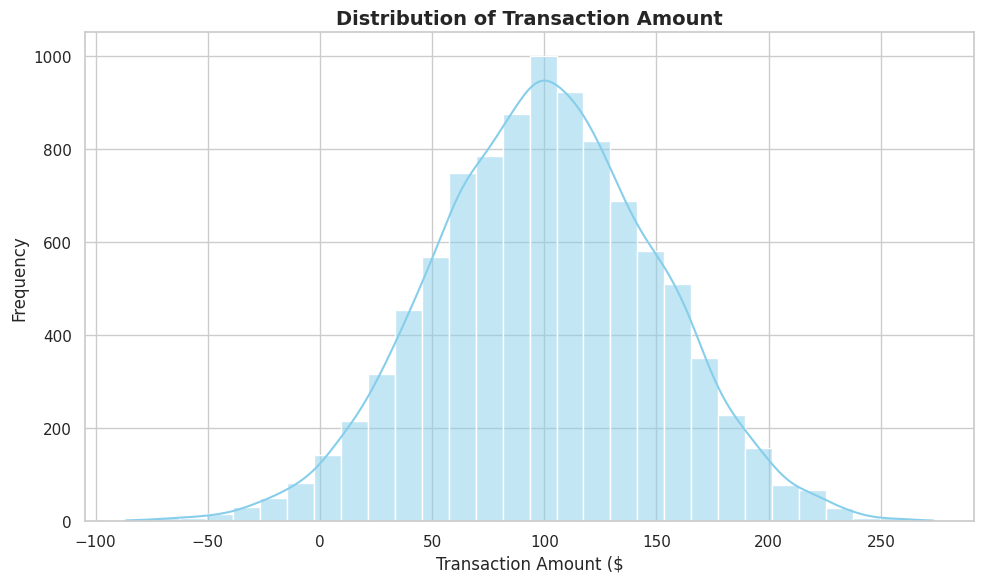

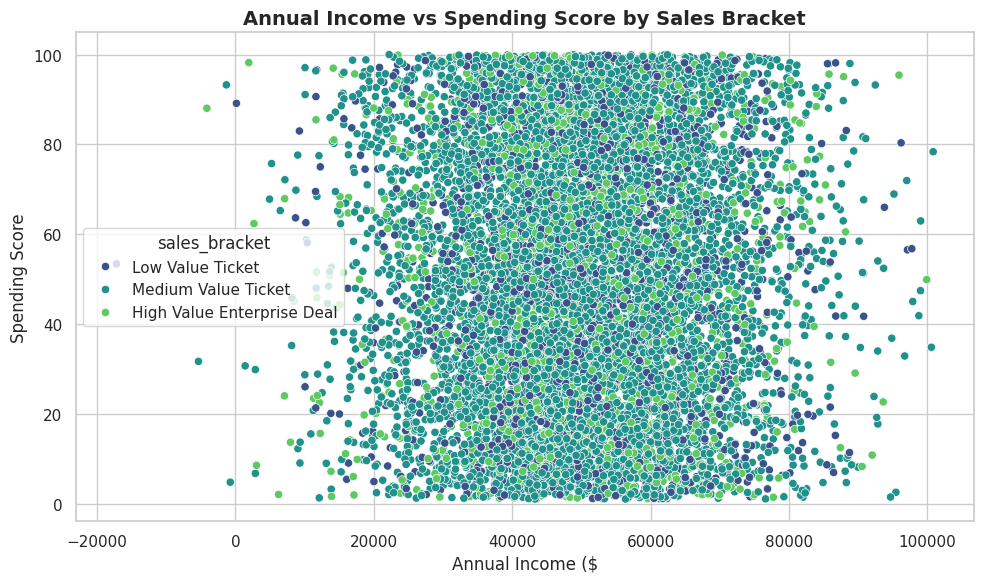

In [14]:
import matplotlib.pyplot as plt
import seaborn as sns
import os

sns.set_theme(style="whitegrid")
plt.rcParams['figure.figsize'] = (10, 6)

plt.figure(figsize=(10, 6))
sns.histplot(df['transaction_amount'].dropna(), bins=30, kde=True, color='skyblue')
plt.title("Distribution of Transaction Amount", fontsize=14, fontweight='bold')
plt.xlabel("Transaction Amount ($")
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.scatterplot(data=df, x='annual_income', y='spending_score', hue='sales_bracket', palette='viridis')
plt.title("Annual Income vs Spending Score by Sales Bracket", fontsize=14, fontweight='bold')
plt.xlabel("Annual Income ($")
plt.ylabel("Spending Score", fontsize=12)
plt.tight_layout()
plt.show()

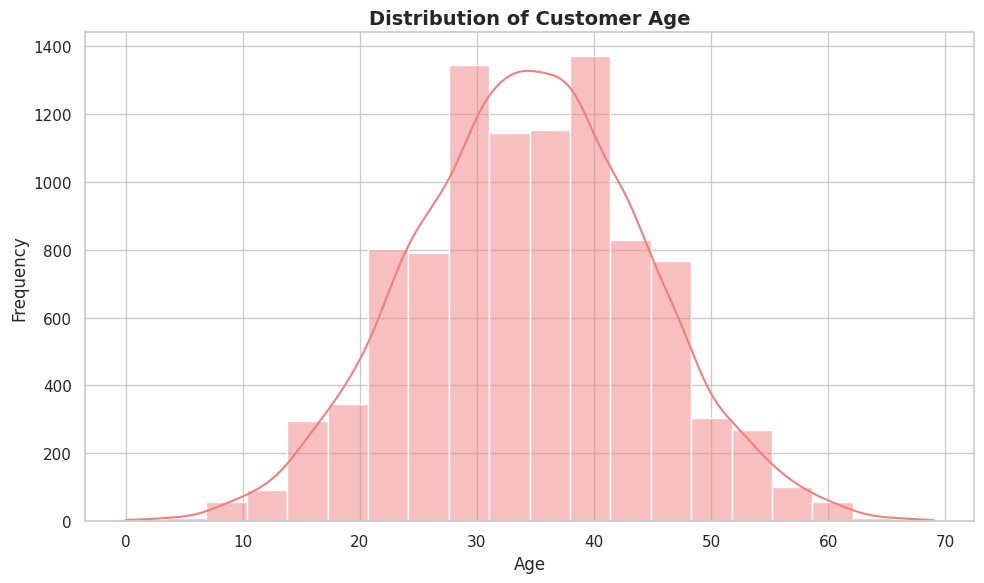

/tmp/ipykernel_4399/2367114935.py:13: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(data=df, x='sales_bracket', y='transaction_amount', palette='pastel')


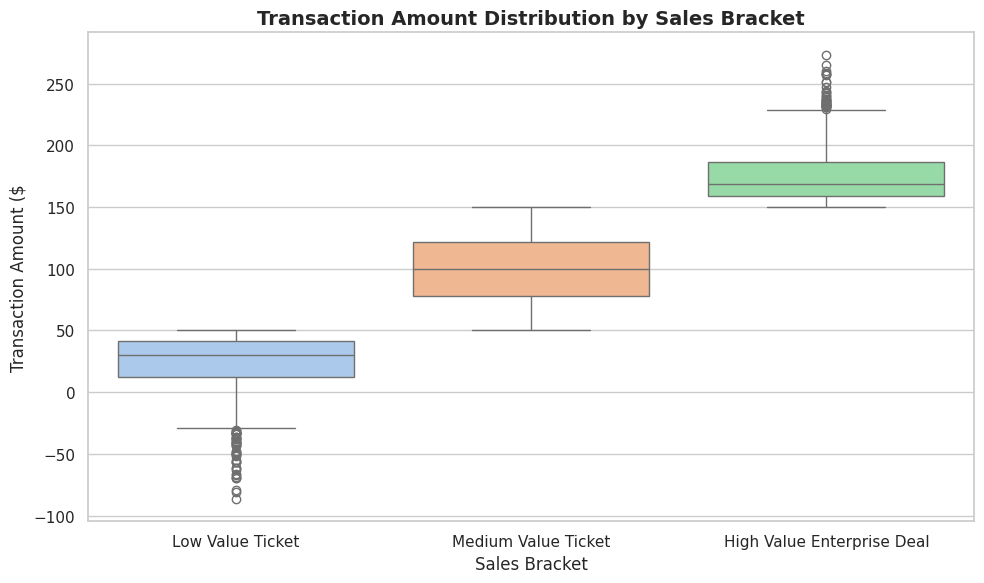

In [15]:
import matplotlib.pyplot as plt
import seaborn as sns

plt.figure(figsize=(10, 6))
sns.histplot(df['age'].dropna(), bins=20, kde=True, color='lightcoral')
plt.title("Distribution of Customer Age", fontsize=14, fontweight='bold')
plt.xlabel("Age", fontsize=12)
plt.ylabel("Frequency", fontsize=12)
plt.tight_layout()
plt.show()

plt.figure(figsize=(10, 6))
sns.boxplot(data=df, x='sales_bracket', y='transaction_amount', palette='pastel')
plt.title("Transaction Amount Distribution by Sales Bracket", fontsize=14, fontweight='bold')
plt.xlabel("Sales Bracket", fontsize=12)
plt.ylabel("Transaction Amount ($")
plt.tight_layout()
plt.show()